# **Austria GP 2026**
## Results and Lap Analysis

In [51]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot
import Sliplib.battle_finder as battle

importlib.reload(slipclassify)
importlib.reload(grid_sum)
importlib.reload(battle)

<module 'Sliplib.battle_finder' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Austria_GP/notebooks/../../Sliplib/battle_finder.py'>

In [52]:
# Load Session
session_Q = sl.load_gp(2025,"Austrian Grand Prix","Q")
session_Q.load()

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '12'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information 

### Result Inspection
Inspect Results of Qualifying Sessions

In [53]:
# Import Session Result
ses_res = session_Q.results
ses_res

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,,NaN,0 days 00:01:04.672000,0 days 00:01:04.410000,0 days 00:01:03.971000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,2.0,,NaN,0 days 00:01:05.197000,0 days 00:01:04.734000,0 days 00:01:04.492000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,,NaN,0 days 00:01:04.966000,0 days 00:01:04.556000,0 days 00:01:04.554000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,4.0,,NaN,0 days 00:01:05.115000,0 days 00:01:04.896000,0 days 00:01:04.582000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,5.0,,NaN,0 days 00:01:05.189000,0 days 00:01:04.860000,0 days 00:01:04.763000,NaT,,NaN,NaN
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,6.0,,NaN,0 days 00:01:05.017000,0 days 00:01:05.041000,0 days 00:01:04.926000,NaT,,NaN,NaN
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,7.0,,NaN,0 days 00:01:05.106000,0 days 00:01:04.836000,0 days 00:01:04.929000,NaT,,NaN,NaN
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,8.0,,NaN,0 days 00:01:05.123000,0 days 00:01:04.846000,0 days 00:01:05.132000,NaT,,NaN,NaN
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,9.0,,NaN,0 days 00:01:05.178000,0 days 00:01:05.052000,0 days 00:01:05.276000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,10.0,,NaN,0 days 00:01:05.054000,0 days 00:01:04.846000,0 days 00:01:05.649000,NaT,,NaN,NaN


In [54]:
ses_res.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [55]:
# Display Clean Result
Q_result = slipclassify.clean_result_Quali(ses_res)
Q_result

,Abbreviation,TeamName,Position
4,NOR,McLaren,1.0
16,LEC,Ferrari,2.0
81,PIA,McLaren,3.0
44,HAM,Ferrari,4.0
63,RUS,Mercedes,5.0
30,LAW,Racing Bulls,6.0
1,VER,Red Bull Racing,7.0
5,BOR,Kick Sauber,8.0
12,ANT,Mercedes,9.0
10,GAS,Alpine,10.0


In [56]:
# Export Results of Quali
Q_result.to_csv("../data/Quali_Result.csv")

### Time Analysis

In [57]:
# Load lap data
Q_lap = session_Q.laps
Q_lap

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:23:14.776000,NOR,4,NaT,1.0,1.0,0 days 00:21:47.835000,NaT,NaT,0 days 00:00:38.857000,...,True,McLaren,0 days 00:21:47.835000,2025-06-28 14:09:26.637,1,NaN,False,,False,False
1,0 days 00:24:19.448000,NOR,4,0 days 00:01:04.672000,2.0,1.0,NaT,NaT,0 days 00:00:16.434000,0 days 00:00:28.843000,...,True,McLaren,0 days 00:23:14.776000,2025-06-28 14:10:53.578,1,NaN,False,,False,True
2,0 days 00:25:53.967000,NOR,4,0 days 00:01:34.519000,3.0,1.0,NaT,0 days 00:25:50.712000,0 days 00:00:27.082000,0 days 00:00:37.232000,...,True,McLaren,0 days 00:24:19.448000,2025-06-28 14:11:58.250,1,NaN,False,,False,False
3,0 days 00:32:14.682000,NOR,4,NaT,4.0,2.0,0 days 00:30:50.949000,NaT,NaT,0 days 00:00:38.018000,...,False,McLaren,0 days 00:25:53.967000,2025-06-28 14:13:32.769,1,NaN,False,,False,False
4,0 days 00:33:19.559000,NOR,4,0 days 00:01:04.877000,5.0,2.0,NaT,NaT,0 days 00:00:16.407000,0 days 00:00:28.763000,...,False,McLaren,0 days 00:32:14.682000,2025-06-28 14:19:53.484,1,NaN,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,0 days 00:29:22.752000,HUL,27,0 days 00:01:05.606000,5.0,2.0,NaT,NaT,0 days 00:00:16.581000,0 days 00:00:29.067000,...,False,Kick Sauber,0 days 00:28:17.146000,2025-06-28 14:15:55.948,1,NaN,False,,False,True
306,0 days 00:30:41.854000,HUL,27,0 days 00:01:19.102000,6.0,2.0,NaT,0 days 00:30:38.410000,0 days 00:00:18.124000,0 days 00:00:31.906000,...,False,Kick Sauber,0 days 00:29:22.752000,2025-06-28 14:17:01.554,1,NaN,False,,False,False
307,0 days 00:33:51.398000,HUL,27,NaT,7.0,3.0,0 days 00:32:16.554000,NaT,NaT,0 days 00:00:36.674000,...,True,Kick Sauber,0 days 00:30:41.854000,2025-06-28 14:18:20.656,1,NaN,False,,False,False
308,0 days 00:34:57.173000,HUL,27,0 days 00:01:05.775000,8.0,3.0,NaT,NaT,0 days 00:00:16.479000,0 days 00:00:29.455000,...,True,Kick Sauber,0 days 00:33:51.398000,2025-06-28 14:21:30.200,1,NaN,False,,False,True


In [58]:
# Fastest Lap
fastest_lap = Q_lap.pick_fastest()
fastest_lap

Time                      0 days 01:25:47.360000
Driver                                       NOR
DriverNumber                                   4
LapTime                   0 days 00:01:03.971000
LapNumber                                   17.0
Stint                                        6.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:16.285000
Sector2Time               0 days 00:00:28.436000
Sector3Time               0 days 00:00:19.250000
Sector1SessionTime        0 days 01:24:59.674000
Sector2SessionTime        0 days 01:25:28.110000
Sector3SessionTime        0 days 01:25:47.360000
SpeedI1                                    316.0
SpeedI2                                    252.0
SpeedFL                                    286.0
SpeedST                                    318.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [59]:
# Make it pretty
pretty_fast = slipclassify.analyse_fastest(fastest_lap)
pretty_fast

,Name,Value
0,Driver,NOR
1,LapNumber,17.0
2,LapTime,1:03.971
3,Stint,6.0
4,Compound,SOFT


In [60]:
# Get the total lap, stint made by each driver
lap_stint_summary = slipclassify.get_lap_stint(Q_lap)
lap_stint_summary

,Driver,TotalLaps,TotalStint
0,NOR,18,6
1,LEC,21,7
2,PIA,19,6
3,HAM,21,7
4,RUS,18,6
5,LAW,17,6
6,VER,18,6
7,BOR,21,7
8,ANT,17,6
9,GAS,21,7


In [61]:
# Extract the data
lap_stint_summary.to_csv("../data/Quali_Lap_stint.csv")

In [62]:
# Analyse Fresh Tyre Period
ft_period = slipclassify.get_fresh_tyre_period(Q_lap)
ft_period

,Driver,TyrePeriod
5,LAW,15
2,PIA,13
3,HAM,12
0,NOR,12
13,COL,12
4,RUS,12
1,LEC,9
6,VER,9
9,GAS,9
10,ALO,9


In [63]:
# Extract Data
ft_period.to_csv("../data/Fresh_Tyre_Period.csv",index=False)

## Race Result Analysis

In [64]:
# Load Race Session
R_session = sl.load_gp(2025,"Austrian Grand Prix","R")
R_session.load()

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', 

In [65]:
# Load Result
R_result = R_session.results
R_result

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:23:47.693000,Finished,25.0,70.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,3.0,NaT,NaT,NaT,0 days 00:00:02.695000,Finished,18.0,70.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,3,2.0,NaT,NaT,NaT,0 days 00:00:19.820000,Finished,15.0,70.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:29.020000,Finished,12.0,70.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,5.0,5,5.0,NaT,NaT,NaT,0 days 00:01:02.396000,Finished,10.0,70.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:01:07.754000,Finished,8.0,70.0
14,14,F ALONSO,ALO,alonso,Aston Martin,229971,aston_martin,Fernando,Alonso,Fernando Alonso,...,7.0,7,11.0,NaT,NaT,NaT,0 days 00:00:01.437000,Lapped,6.0,69.0
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,8.0,8,8.0,NaT,NaT,NaT,0 days 00:00:01.952000,Lapped,4.0,69.0
27,27,N HULKENBERG,HUL,hulkenberg,Kick Sauber,01C00E,sauber,Nico,Hulkenberg,Nico Hulkenberg,...,9.0,9,20.0,NaT,NaT,NaT,0 days 00:00:07.720000,Lapped,2.0,69.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,10.0,10,17.0,NaT,NaT,NaT,0 days 00:00:09.986000,Lapped,1.0,69.0


In [66]:
clear_race = slipclassify.clean_result_race(R_result)
clear_race

,Abbreviation,TeamName,ClassifiedPosition
4,NOR,McLaren,1
81,PIA,McLaren,2
16,LEC,Ferrari,3
44,HAM,Ferrari,4
63,RUS,Mercedes,5
30,LAW,Racing Bulls,6
14,ALO,Aston Martin,7
5,BOR,Kick Sauber,8
27,HUL,Kick Sauber,9
31,OCO,Haas F1 Team,10


In [67]:
# Extract Data
clear_race.to_csv("../data/Race_Result.csv",index=False)

### Insights:
- Max got R
- Kimi got R
- Analysing the reason

In [68]:
messages = R_session.race_control_messages
messages

,Time,Category,Message,Status,Flag,Scope,Sector,RacingNumber,Lap
0,2025-06-29 12:20:01,Flag,GREEN LIGHT - PIT EXIT OPEN,None,GREEN,Track,NaN,None,1
1,2025-06-29 12:20:26,Flag,YELLOW IN TRACK SECTOR 3,None,YELLOW,Sector,3.0,None,1
2,2025-06-29 12:20:27,Other,DRS DISABLED IN ZONE 1,None,None,None,NaN,None,1
3,2025-06-29 12:20:36,Flag,CLEAR IN TRACK SECTOR 3,None,CLEAR,Sector,3.0,None,1
4,2025-06-29 12:20:36,Other,DRS ENABLED IN ZONE 1,None,None,None,NaN,None,1
...,...,...,...,...,...,...,...,...,...
112,2025-06-29 14:46:17,Flag,YELLOW IN TRACK SECTOR 9,None,YELLOW,Sector,9.0,None,70
113,2025-06-29 14:46:18,Other,DRS DISABLED IN ZONE 2,None,None,None,NaN,None,70
114,2025-06-29 14:47:32,Flag,CLEAR IN TRACK SECTOR 9,None,CLEAR,Sector,9.0,None,70
115,2025-06-29 14:47:32,Other,DRS ENABLED IN ZONE 2,None,None,None,NaN,None,70


In [69]:
# Check Track Status
track_history = slipclassify.analyse_track_History(messages)
track_history

,Flags,Occurence
0,GREEN,2
1,YELLOW,8
2,None,0
3,CLEAR,10
4,DOUBLE YELLOW,2
5,BLUE,44
6,CHEQUERED,1


### Insights
- No Red Flag in the session
- So, no serious incidents
- But, minor incidents occured

In [70]:
# Position Gain Calculation of Drivers
ret_1 = grid_sum.calc_pos_gain(R_result)
ret_1

,Driver,PositionGain,Status
0,HUL,11.0,Finished
1,OCO,7.0,Finished
2,ALO,4.0,Finished
3,BEA,4.0,Finished
4,STR,2.0,Finished
5,TSU,2.0,Finished
6,HAD,1.0,Finished
7,PIA,1.0,Finished
8,NOR,0.0,Finished
9,BOR,0.0,Finished


## Race Lap Analysis
From the above analysis, the Best Perfomance Drivers to examine are:
- Nico Hulkenberg
- Esteban Ocon
- Lando Norris
- Oscar Piastri
- Charles Leclerc
- Lewis Hamilton

In [71]:
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:12:37.412000,NOR,4,0 days 00:01:28.861000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.326000,...,True,McLaren,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,1.0,False,,False,False
1,0 days 01:14:31.838000,NOR,4,0 days 00:01:54.426000,2.0,1.0,NaT,NaT,0 days 00:00:26.438000,0 days 00:00:53.661000,...,True,McLaren,0 days 01:12:37.412000,2025-06-29 13:19:30.205,4,1.0,False,,False,False
2,0 days 01:16:24.860000,NOR,4,0 days 00:01:53.022000,3.0,1.0,NaT,NaT,0 days 00:00:26.434000,0 days 00:00:50.148000,...,True,McLaren,0 days 01:14:31.838000,2025-06-29 13:21:24.631,41,1.0,False,,False,False
3,0 days 01:17:35.114000,NOR,4,0 days 00:01:10.254000,4.0,1.0,NaT,NaT,0 days 00:00:17.564000,0 days 00:00:31.393000,...,True,McLaren,0 days 01:16:24.860000,2025-06-29 13:23:17.653,1,1.0,False,,False,True
4,0 days 01:18:44.972000,NOR,4,0 days 00:01:09.858000,5.0,1.0,NaT,NaT,0 days 00:00:17.488000,0 days 00:00:31.430000,...,True,McLaren,0 days 01:17:35.114000,2025-06-29 13:24:27.907,1,1.0,False,,False,True


In [72]:
toppers,data= battle.find_top_battles(R_Laps,n=6)
data

['BOR', 'NOR', 'GAS', 'HAD', 'STR', 'ALB', 'VER', 'ANT', 'TSU']

In [73]:
# Import Drivers
hul,oco,nor,pia,lec,ham = slipclassify.pick_athletes(R_Laps,["HUL","OCO","NOR","PIA","LEC","HAM"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
140,0 days 01:12:42.753000,LEC,16,0 days 00:01:34.202000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.122000,...,True,Ferrari,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,3.0,False,,False,False
141,0 days 01:14:34.285000,LEC,16,0 days 00:01:51.532000,2.0,1.0,NaT,NaT,0 days 00:00:24.098000,0 days 00:00:53.387000,...,True,Ferrari,0 days 01:12:42.753000,2025-06-29 13:19:35.546,4,3.0,False,,False,False
142,0 days 01:16:25.878000,LEC,16,0 days 00:01:51.593000,3.0,1.0,NaT,NaT,0 days 00:00:26.530000,0 days 00:00:50.544000,...,True,Ferrari,0 days 01:14:34.285000,2025-06-29 13:21:27.078,41,3.0,False,,False,False
143,0 days 01:17:36.813000,LEC,16,0 days 00:01:10.935000,4.0,1.0,NaT,NaT,0 days 00:00:17.722000,0 days 00:00:31.653000,...,True,Ferrari,0 days 01:16:25.878000,2025-06-29 13:23:18.671,1,3.0,False,,False,True
144,0 days 01:18:47.040000,LEC,16,0 days 00:01:10.227000,5.0,1.0,NaT,NaT,0 days 00:00:17.387000,0 days 00:00:31.363000,...,True,Ferrari,0 days 01:17:36.813000,2025-06-29 13:24:29.606,1,3.0,False,,False,True
145,0 days 01:19:57.250000,LEC,16,0 days 00:01:10.210000,6.0,1.0,NaT,NaT,0 days 00:00:17.441000,0 days 00:00:31.437000,...,True,Ferrari,0 days 01:18:47.040000,2025-06-29 13:25:39.833,1,3.0,False,,False,True
146,0 days 01:21:07.443000,LEC,16,0 days 00:01:10.193000,7.0,1.0,NaT,NaT,0 days 00:00:17.446000,0 days 00:00:31.384000,...,True,Ferrari,0 days 01:19:57.250000,2025-06-29 13:26:50.043,1,3.0,False,,False,True
147,0 days 01:22:17.355000,LEC,16,0 days 00:01:09.912000,8.0,1.0,NaT,NaT,0 days 00:00:17.448000,0 days 00:00:31.269000,...,True,Ferrari,0 days 01:21:07.443000,2025-06-29 13:28:00.236,1,3.0,False,,False,True
148,0 days 01:23:27.478000,LEC,16,0 days 00:01:10.123000,9.0,1.0,NaT,NaT,0 days 00:00:17.561000,0 days 00:00:31.283000,...,True,Ferrari,0 days 01:22:17.355000,2025-06-29 13:29:10.148,1,3.0,False,,False,True
149,0 days 01:24:37.547000,LEC,16,0 days 00:01:10.069000,10.0,1.0,NaT,NaT,0 days 00:00:17.714000,0 days 00:00:31.092000,...,True,Ferrari,0 days 01:23:27.478000,2025-06-29 13:30:20.271,1,3.0,False,,False,True


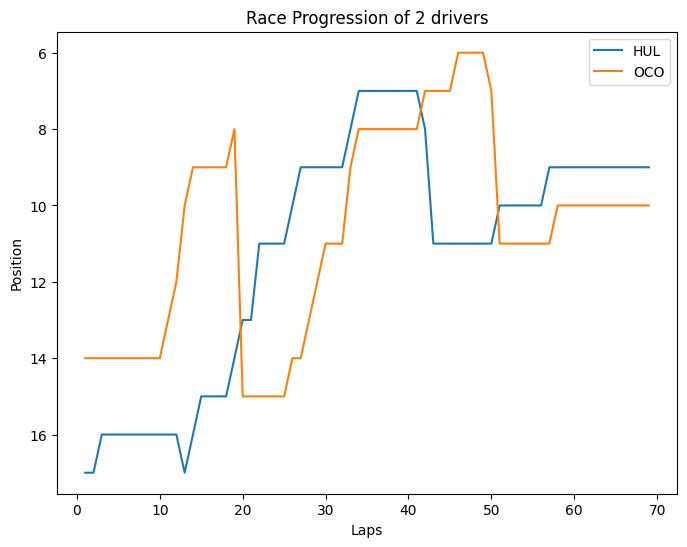

In [74]:
# Plot showing the 2 Contenders
slplot.plot_race_progression([hul,oco])

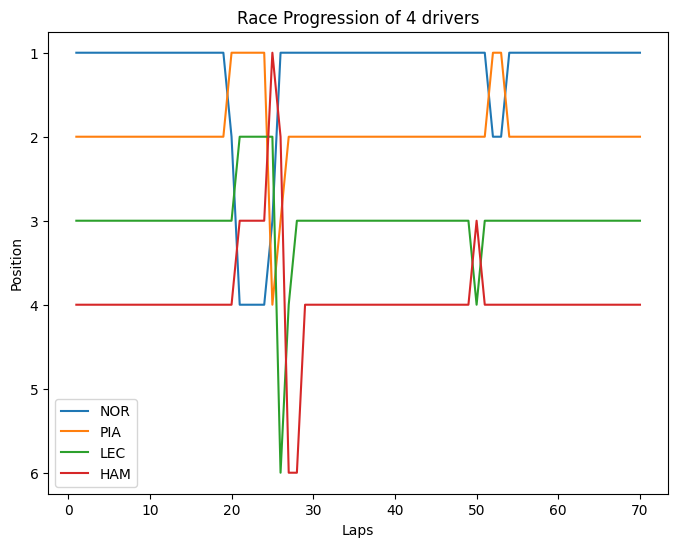

In [75]:
# Plots showing The Top grid
slplot.plot_race_progression([nor,pia,lec,ham])